# Assignment 7

## Name: Sanyam Goel

In [1]:
import pandas as pd

import numpy as np

import string

import seaborn as sns

from nltk.corpus import stopwords

def read_dataframe(path: str) -> pd.DataFrame:

    ''' This method reads data set from a give file on a path
    
    Args:
        path (str): path to file.

    Returns:
        DataFrame: The created data frame.
    '''
   
    return pd.read_json(path)

def pre_process_word(word: str) -> str:

    ''' This method pre processes eacg work by replacing punctuations with empty string
    
    Args:
        word (str): word.

    Returns:
        sanatized word.
    '''
    
    return word.translate(str.maketrans('', '', string.punctuation)).lower() 

def pre_process_words(data_frame: pd.DataFrame, stop_words: stop_words) -> pd.Series:
    
    ''' This method pre processes all words ( ingredients of all cuisines
    
    Args:
        data_frame (pd.DataFrame): read data frame.
        stop_words: stop_words

    Returns:
         pd.Series of processed words.
    '''

    #Convert each ingredient into lowercase per cuisine
    return (data_frame["ingredients"]
        .apply(lambda ingredients: [ pre_process_word(ingredient)
                             for ingredient in ingredients
                             if ingredient.lower() not in stop_words ]))

def find_unique_words(all_words: pd.Series) -> None:
    
    ''' This method finds all unique words in the series
    
    Args:
        all_words (pd.Series): all words.

    Returns:
         None.
    '''
    
    return all_words.unique()

def plot_top_by_count(all_words: pd.Series, count: int) -> None:
       
    ''' This method plots top 'count' number of ingredients
    
    Args:
        count (int): Number of top bars to be constructed.

    Returns:
         None.
    '''
    
    sns.set()

    #Find top number of required bars
    found_words = all_words.value_counts().head(count)

    #Plot bars
    found_words.sort_values(ascending=True).plot.barh()
    

def plot_grouped_top_by_count(data_frame: pd.DataFrame, count:int) -> None:
    
    ''' This method plots top 'count' number of ingredients grouped by cuisine
    
    Args:
        data_frame (pd.DataFrame): Data frame to be analysed
        count (int): Number of top bars to be constructed.

    Returns:
         None.
    '''
    
    df_exploded = data_frame.explode("ingredients")

    #Count ingredients per cuisine
    ingredient_counts = ( df_exploded.groupby(["cuisine", "ingredients"])
        .size().reset_index(name="count") )

    #Find top number of required bars
    cuisines = ingredient_counts.sort_values(by='count', ascending=False).head(count)
    
    cuisines["label"] = cuisines["cuisine"] + " | " + cuisines["ingredients"]
    
    sns.set()

    #Plot bars
    sns.barplot(data=cuisines, x="count", y="label")

def create_unigrams(data_frame: pd.DataFrame)-> None:

    ''' This method finds all unique words in the series
    
    Args:
        all_words (pd.Series): all words.

    Returns:
         None.
    '''
    
    df_exploded = data_frame.explode("ingredients")

    #Find unigrams
    vocabulary_data_frame = (df_exploded.groupby("cuisine")["ingredients"]
        .apply(lambda x: sorted(set(x))).reset_index(name="vocabulary")) 
           
    print(vocabulary_data_frame)

def calculate_dice_coeff(data_frame: pd.DataFrame):

    ''' This method calculates dice coeff between cuisines
    
    Args:
        data_frame (pd.DataFrame): Data frame to be analysed

    Returns:
         None.
    '''

    #Explode all cuisines by ingredients
    df_exploded = data_frame.explode("ingredients") 

    #Collect all unique cuisines
    cuisines = df_exploded["cuisine"].unique() 

    #Collect all unique ingredients
    ingredients = df_exploded["ingredients"].unique()

    #Assign index to each cuisines for matrix reference
    cuisine_index = {cuisine:index for index,cuisine in enumerate(cuisines)} 

    #Assign index to each ingredient for matrix reference
    ingredient_index = {ingredient:index for index,ingredient in enumerate(ingredients)}

    #Initialize matrix with cuisine row and ingredient index
    matrix = np.zeros((len(cuisines), len(ingredients)), dtype=int)

    #Set 1 for ingrednet usied in that cuisine
    for _, row in df_exploded.iterrows(): 
        matrix[cuisine_index[row["cuisine"]], ingredient_index[row["ingredients"]]] = 1

    #Calculate sum of all common ingredients between each pair of cuisines
    intersection = np.dot(matrix,matrix.T)

    # caclulate number of ingredients per cuisine
    sizes = matrix.sum(axis=1)

    # caclulate dice coefficient
    dice_coeff = 2 * intersection / np.outer(sizes, sizes)

    dice_data_frame = pd.DataFrame(dice_coeff, index=cuisines, columns=cuisines)

    sns.set()

    #Plot heatmap
    sns.heatmap(dice_data_frame, annot=False, cmap="Blues", fmt=".2f") 

In [2]:
stop_words = set(stopwords.words("english"))

data_frame: pd.DataFrame = read_dataframe("data/train.json")

data_frame["ingredients"] = pre_process_words(data_frame, stop_words)

all_words = data_frame["ingredients"].explode()

In [3]:
unique_words = find_unique_words(all_words)
print(unique_words)

['romaine lettuce' 'black olives' 'grape tomatoes' ... 'lop chong'
 'tomato garlic pasta sauce' 'crushed cheese crackers']


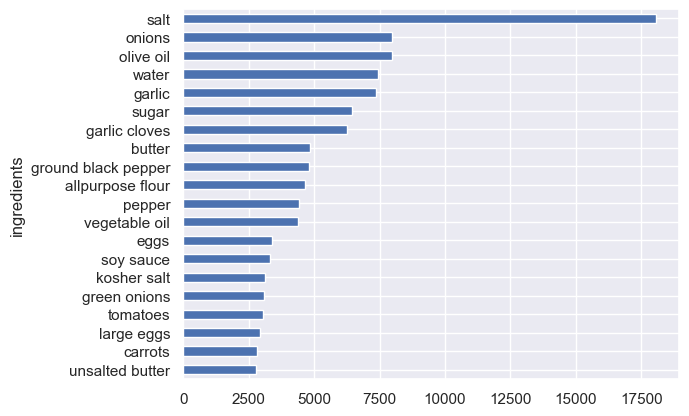

In [4]:
plot_top_by_count(all_words, 20)

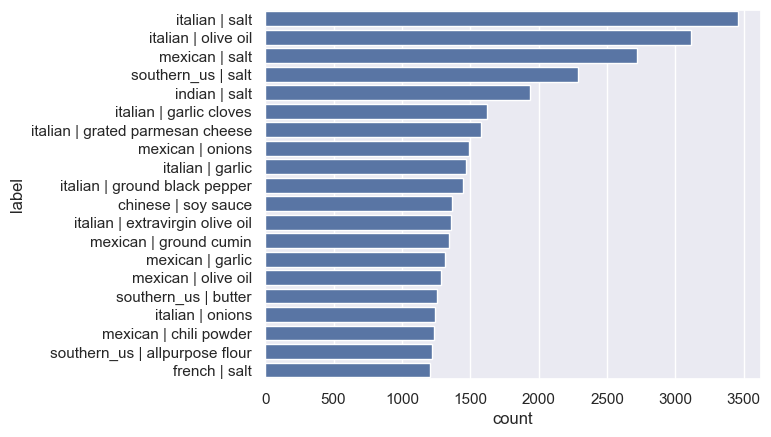

In [5]:
plot_grouped_top_by_count(data_frame,20)

In [6]:
create_unigrams(data_frame)

         cuisine                                         vocabulary
0      brazilian  [1 lowfat milk, 2 reducedfat milk, acai juice,...
1        british  [2 reducedfat milk, active dry yeast, aged che...
2   cajun_creole  [    oz tomato sauce, 1 lowfat milk, 2 reduced...
3        chinese  [33 less sodium smoked fully cooked ham, abalo...
4       filipino  [7 up, accent seasoning, achiote powder, acorn...
5         french  [    oz tomato sauce, 1 lowfat chocolate milk,...
6          greek  [1 lowfat milk, 10 oz frozen chopped spinach t...
7         indian  [   oz tomato paste, 1 lowfat milk, 14 oz swee...
8          irish  [1 lowfat buttermilk, 1 lowfat milk, 2 reduced...
9        italian  [    oz tomato sauce,    oz tomato paste, 1 lo...
10      jamaican  [ackee, active dry yeast, adobo sauce, adobo s...
11      japanese  [1 lowfat milk, 2 reducedfat milk, a taste of ...
12        korean  [agave nectar, all purpose unbleached flour, a...
13       mexican  [    oz tomato sauce,    oz to

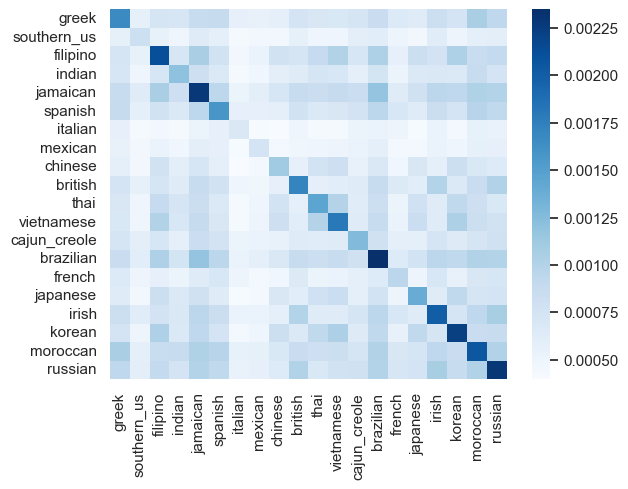

In [7]:
calculate_dice_coeff(data_frame)